# Circular Plastics Economy Thesis 

##  Surrogate Modeling of Sorting Quality Impacts on PyOil Yield, Contamination, and Profitability

This project builds a decision-support model for the circular plastics econonomy senior design project. A model is created in order to understand how upstream sorting quality (Pyoil Composition) affects, product distribution, contamination levels, downstream purification risk, and an economic analysis.

This notebook contains:

1. Project Scope and Overview,  
2. Assumptions,  
3. Synthetic Data Generation,  
4. Data Validation by Literature Trends ,  
5. Surrogate Model Development,  
6. Economic Analysis,  
7. Sensitivity Analysis  
8. Model Optimization
9. Bayesian Optimization
10. Decision Insights
11. Limitations
12. Future Work


# Project Overview

An issue with a plastics circular economy is that is hindered by waste collection and sorting performance to downstream process feasibility. Plastic pyrolysis performance is sensitive to feed composition, contamination, and operating conditions. Althopugh this is the case, integrated data that couples sorting quality, mixed-feed pyrolysis, contamination loads, and economic outcomes are scarce.

This project addresses that gap by constructing a mechanistic scenario that trains a surrogate model that rapidly predicts key process outputs. This model should answer the design question:

> How clean does the sorted plastic waste need to be for a pyrolysis-based circular plastics system to remain economically viable?

This model takes into account commonly used polymers like PE, PP, PS, PET, and PVC, as these polymers all behave differently during pyrolysis, generating different products and contaminants (PVC).


# Project Scope

## Included in scope
- Differing Polymer Composition
- Sorting Efficiency and Sorting Errors
- Contamination Indicators such as Moisture, Inert Solids, and Chloride Variables
- Pyrolysis Operating Conditions
- Surrogate Prediction of Product Yields and Contamination Levels
- Economic Analysis
- Sensitvity Analysis

## Excluded from scope
- Reactor Kinetics
- Reaction Chemistry
- Process Simulation
- Corrosion Modeling
 



# Background / Heuristics 

The logic for the synthetic data and surrogate model is based on qualitative trends reported for mixed-plastic pyrolysis:

- **PE and PP** generally favor liquid hydrocarbon production and often contribute strongly to naphtha and gas-oil products.
- **PS** tends to produce aromatic-rich liquids and can still support relatively high liquid yields.
- **PET** may increase oxygenated species, raising residue formation and acidity.
- **PVC** is a major source of contamination and downstream reliability concerns due to the production of chlorine.
- **Higher temperature and longer residence time** generally increase cracking severity and gas production.
- **Moisture and inert contamination** reduce feed quality and can increase downstream issues.


# Synthetic Data Generation

This section generates a synthetic dataset using a stochastic model (Dirichelt Distribution). Random sampling is used to create broad scenario coverage, while heuristics preserve expected relationships between inputs and outputs.

The generator includes:
- Polymer Fractions = 1
- Sorting Vairability 
- Process Conditions
- Product Yields
- Contamination Values (Chloride Load and Acid Number)

Dirichlet Distribution was used since plastic waste is compositionally variable, this allows for random sampling to account for a range of operating and feedstock scenarios rather than modeling a singular composiition case. The distribution is weighted for PE and PP being the largest fractions since plastic waste is typically dominated by polyolefins while PET and PVC are the lowest fractions due to them being the least common in pyoil. Synergistic effects were taken into account to make sure polymers are not treated independently. For example, PE and PP mixtures can improve liquid/gas formation, and PS can donate radicals or affect cracking behavior.

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
plt.rcParams["figure.dpi"] = 120

In [ ]:
def generate_pyoil_dataset(n_samples=2000, random_state=42):
    rng = np.random.default_rng(random_state)
    rows = []

    for _ in range(n_samples):
        # Polymer Compositions
        polymer_frac = rng.dirichlet([4.0, 4.0, 1.5, 1.2, 0.8])
        polymer_PE, polymer_PP, polymer_PS, polymer_PET, polymer_PVC = polymer_frac

        # Sorting Variables
        inert_contaminant_frac = rng.uniform(0.0, 0.15)
        moisture_frac = rng.uniform(0.0, 0.12)
        sorting_efficiency_total = rng.uniform(0.70, 0.95)
        sorting_false_negative_rate = rng.uniform(0.05, 0.30) # Accounts for Valuable Feedstock Lost
        sorting_false_positive_rate = rng.uniform(0.0, 0.05) # Accounts for contaminatns entering pyrolysis
        PVC_capture_efficiency = rng.uniform(0.65, 0.98)
        metal_removal_efficiency = rng.uniform(0.60, 0.95)

        # Operating Conditions
        pyrolysis_temp_C = rng.uniform(420, 560)
        residence_time_s = rng.uniform(5, 60)
        quench_temp_F = rng.uniform(100, 120)
        catalyst_flag = rng.integers(0, 2)
        batch_vs_continuous = rng.integers(0, 2)

        # Feed descriptors
        feed_LHV = (
            46.0 * polymer_PE
            + 46.0 * polymer_PP
            + 41.0 * polymer_PS
            + 23.0 * polymer_PET
            + 20.0 * polymer_PVC
            - 8.0 * moisture_frac
            - 5.0 * inert_contaminant_frac
            + rng.normal(0, 0.4)

        )
        
        feed_H_C_ratio = (      
            2.0 * polymer_PE
            + 2.0 * polymer_PP
            + 1.0 * polymer_PS
            + 0.4 * polymer_PET
            + 0.7 * polymer_PVC
            - 0.5 * inert_contaminant_frac
            + rng.normal(0, 0.03)
        )

        feed_O_C_ratio = (      
            0.35 * polymer_PET
            + 0.10 * moisture_frac
            + 0.05 * inert_contaminant_frac
            + rng.normal(0, 0.01)
        )

        feed_H_C_ratio = max(feed_H_C_ratio, 0.1)
        feed_O_C_ratio = max(feed_O_C_ratio, 0.0)

        feed_Cl_ppm = (
            40
            + 1200 * polymer_PVC * (1 - PVC_capture_efficiency)
            + 120 * sorting_false_negative_rate
            + rng.normal(0, 8)
        )
        feed_Cl_ppm = max(feed_Cl_ppm, 5)

        feed_Ca_ppm = (
            20
            + 180 * inert_contaminant_frac * (1 - metal_removal_efficiency)
            + rng.normal(0, 4)
        )
        feed_Ca_ppm = max(feed_Ca_ppm, 1)

        feed_Si_ppm = (
            15
            + 120 * inert_contaminant_frac * (1 - metal_removal_efficiency)
            + rng.normal(0, 3)
        )
        feed_Si_ppm = max(feed_Si_ppm, 1)

        #Increases with increased PET, Moisture, and PVC
        feed_acid_precursor_index = (
            0.3
            + 2.0 * polymer_PET
            + 1.2 * moisture_frac
            + 0.4 * polymer_PVC
            + rng.normal(0, 0.05)
        )
        feed_acid_precursor_index = max(feed_acid_precursor_index, 0.05)

            
        # Yield and contamination model

        temp_factor = (pyrolysis_temp_C - 525) / 100.0
        excess_residence = max(0, residence_time_s - 25) / 20

        # polymer baseline yields (literature)
        PE_oil, PE_gas, PE_solid = 0.95, 0.04, 0.01
        PP_oil, PP_gas, PP_solid = 0.96, 0.04, 0.00
        PS_oil, PS_gas, PS_solid = 0.94, 0.02, 0.04
        PET_oil, PET_gas, PET_solid = 0.54, 0.09, 0.32
        PVC_oil, PVC_gas, PVC_solid = 0.60, 0.15, 0.25

        baseline_oil = (
            polymer_PE * PE_oil +
            polymer_PP * PP_oil +
            polymer_PS * PS_oil +
            polymer_PET * PET_oil +
            polymer_PVC * PVC_oil
        )

        baseline_gas = (
            polymer_PE * PE_gas +
            polymer_PP * PP_gas +
            polymer_PS * PS_gas +
            polymer_PET * PET_gas +
            polymer_PVC * PVC_gas
        )

        baseline_solid = (
            polymer_PE * PE_solid +
            polymer_PP * PP_solid +
            polymer_PS * PS_solid +
            polymer_PET * PET_solid +
            polymer_PVC * PVC_solid
        )


        # PS/PE synergy
        ps_pe_interaction = polymer_PS * polymer_PE

        oil_boost = 0.097 * ps_pe_interaction
        gas_reduction = 0.079 * ps_pe_interaction

        baseline_oil += oil_boost
        baseline_gas -= gas_reduction

        # PET penalty
        pet_excess = max(0, polymer_PET - 0.20)

        baseline_oil -= 0.35 * pet_excess
        baseline_solid += 0.40 * pet_excess

        
        # Contamination penalty
        contamination_penalty = (
            0.30 * inert_contaminant_frac +
            0.20 * moisture_frac +
            0.10 * sorting_false_positive_rate
        )

        baseline_oil -= contamination_penalty
        baseline_solid += 0.70 * contamination_penalty
        baseline_gas += 0.30 * contamination_penalty

        # temperature severity effects
        if pyrolysis_temp_C < 430:
            baseline_oil *= 0.92
            baseline_solid *= 1.12

        elif 430 <= pyrolysis_temp_C <= 520:
            # favorable liquid window
            baseline_oil *= 1.05
            baseline_gas *= 0.95

        else:
            # high severity: secondary cracking to gas
            severity = (pyrolysis_temp_C - 520) / 80
            baseline_oil -= 0.06 * severity
            baseline_gas += 0.08 * severity
            baseline_solid += 0.02 * severity

        # residence penalty
        baseline_oil -= 0.07 * excess_residence
        baseline_gas += 0.04 * excess_residence
        baseline_solid += 0.03 * excess_residence

        # catalyst effects
        if catalyst_flag == 1:
            catalyst_effect = 0.03

            if 430 <= pyrolysis_temp_C <= 520:
                baseline_oil += catalyst_effect
                baseline_solid -= 0.015
            else:
                baseline_gas += 0.015
                baseline_solid -= 0.005

        # reactor/data heterogeneity
        heterogeneity_factor = rng.normal(1.0, 0.03)

        baseline_oil *= heterogeneity_factor
        baseline_gas *= rng.normal(1.0, 0.04)
        baseline_solid *= rng.normal(1.0, 0.04)

        # prevent invalid values
        baseline_oil = max(baseline_oil, 0.05)
        baseline_gas = max(baseline_gas, 0.01)
        baseline_solid = max(baseline_solid, 0.01)

        # split liquid oil into naphtha + gas oil
        naphtha_fraction = (
            0.42
            + 0.08 * polymer_PS
            - 0.05 * polymer_PET
            - 0.04 * polymer_PVC
        )

        naphtha_fraction = np.clip(naphtha_fraction, 0.30, 0.60)

        naphtha_yield = baseline_oil * naphtha_fraction
        gas_oil_yield = baseline_oil * (1 - naphtha_fraction)

        pygas_yield = baseline_gas
        heavy_residue_yield = baseline_solid

        # normalize yields
        raw = np.array([
            pygas_yield,
            naphtha_yield,
            gas_oil_yield,
            heavy_residue_yield
        ])
        raw = raw + rng.normal(0, 0.012, size=4)
        raw = np.clip(raw, 0.01, None)
        yields = raw / raw.sum()

        pygas_yield, naphtha_yield, gas_oil_yield, heavy_residue_yield = yields

        chloride_load_ppm = (
            10
            + 900 * polymer_PVC * (1 - PVC_capture_efficiency)
            + 0.3 * feed_Cl_ppm
            + 100 * sorting_false_positive_rate
            + 40 * inert_contaminant_frac
            + rng.normal(0, 5)
        )

        chloride_load_ppm = max(chloride_load_ppm, 1)

        acid_number = (
            0.3
            + 6.0 * polymer_PET
            + 2.0 * moisture_frac
            + 1.5 * polymer_PVC
            + 0.002 * chloride_load_ppm
            + rng.normal(0, 0.1)
        )

        acid_number = max(acid_number, 0.01)

        corrosion_index = (
            0.6 * (chloride_load_ppm / 100)
            + 0.4 * acid_number
        )
        
        fouling_index = (
            0.5 * heavy_residue_yield
            + 0.3 * (feed_Ca_ppm / 1000)
            + 0.2 * (feed_Si_ppm / 1000)
        )

        polyolefin_frac = polymer_PE + polymer_PP
        oxygenated_polymer_frac = polymer_PET
        halogenated_polymer_frac = polymer_PVC

        rows.append({
            "polymer_PE": polymer_PE,
            "polymer_PP": polymer_PP,
            "polymer_PS": polymer_PS,
            "polymer_PET": polymer_PET,
            "polymer_PVC": polymer_PVC,
            "inert_contaminant_frac": inert_contaminant_frac,
            "moisture_frac": moisture_frac,
            "sorting_efficiency_total": sorting_efficiency_total,
            "sorting_false_negative_rate": sorting_false_negative_rate,
            "sorting_false_positive_rate": sorting_false_positive_rate,
            "PVC_capture_efficiency": PVC_capture_efficiency,
            "metal_removal_efficiency": metal_removal_efficiency,
            "feed_LHV": feed_LHV,
            "feed_Cl_ppm": feed_Cl_ppm,
            "feed_Ca_ppm": feed_Ca_ppm,
            "feed_Si_ppm": feed_Si_ppm,
            "feed_acid_precursor_index": feed_acid_precursor_index,
            "pyrolysis_temp_C": pyrolysis_temp_C,
            "residence_time_s": residence_time_s,
            "quench_temp_F": quench_temp_F,
            "catalyst_flag": catalyst_flag,
            "batch_vs_continuous": batch_vs_continuous,
            "pygas_yield": pygas_yield,
            "naphtha_yield": naphtha_yield,
            "gas_oil_yield": gas_oil_yield,
            "heavy_residue_yield": heavy_residue_yield,
            "chloride_load_ppm": chloride_load_ppm,
            "acid_number": acid_number,
            "corrosion_index": corrosion_index,
            "fouling_index": fouling_index,
            "feed_H_C_ratio": feed_H_C_ratio,
            "feed_O_C_ratio": feed_O_C_ratio,
            "polyolefin_frac": polyolefin_frac,
            "oxygenated_polymer_frac": oxygenated_polymer_frac,
            "halogenated_polymer_frac": halogenated_polymer_frac,
        })

    return pd.DataFrame(rows)

df = generate_pyoil_dataset(n_samples=2000, random_state=42)
df.head()

,polymer_PE,polymer_PP,polymer_PS,polymer_PET,polymer_PVC,inert_contaminant_frac,moisture_frac,sorting_efficiency_total,sorting_false_negative_rate,sorting_false_positive_rate,...,heavy_residue_yield,chloride_load_ppm,acid_number,corrosion_index,fouling_index,feed_H_C_ratio,feed_O_C_ratio,polyolefin_frac,oxygenated_polymer_frac,halogenated_polymer_frac
0,0.355238,0.439692,0.108710,0.070615,0.025745,0.096580,0.098731,0.810854,0.106810,0.027729,...,0.092937,40.228398,0.957780,0.624483,0.056986,1.683698,0.035896,0.794930,0.070615,0.025745
1,0.405523,0.385426,0.115097,0.087104,0.006850,0.001104,0.094431,0.866213,0.226291,0.039036,...,0.044747,37.927007,1.166661,0.694226,0.032720,1.726034,0.041612,0.790950,0.087104,0.006850
2,0.258023,0.443642,0.153760,0.050641,0.093934,0.024191,0.060125,0.738078,0.224080,0.022308,...,0.066190,60.089409,0.925760,0.730841,0.043996,1.642998,0.015892,0.701665,0.050641,0.093934
3,0.236251,0.421892,0.183073,0.101867,0.056918,0.074099,0.039583,0.736131,0.075851,0.029382,...,0.080289,59.037623,1.209526,0.838036,0.053729,1.512430,0.046452,0.658142,0.101867,0.056918
4,0.367979,0.142325,0.121109,0.108464,0.260122,0.005612,0.066582,0.792731,0.257447,0.040413,...,0.122256,120.558173,1.733575,1.416779,0.071312,1.350733,0.032645,0.510304,0.108464,0.260122


In [34]:

from sklearn.model_selection import train_test_split

input_cols = [
    "polymer_PE",
    "polymer_PP",
    "polymer_PS",
    "polymer_PET",
    "polymer_PVC",
    "inert_contaminant_frac",
    "moisture_frac",
    "sorting_efficiency_total",
    "sorting_false_negative_rate",
    "sorting_false_positive_rate",
    "PVC_capture_efficiency",
    "metal_removal_efficiency",
    "feed_LHV",
    "feed_Cl_ppm",
    "feed_Ca_ppm",
    "feed_Si_ppm",
    "feed_acid_precursor_index",
    "pyrolysis_temp_C",
    "residence_time_s",
    "quench_temp_F",
    "catalyst_flag",
    "batch_vs_continuous",
    "feed_H_C_ratio",
    "feed_O_C_ratio",
]

output_cols = [
    "pygas_yield",
    "naphtha_yield",
    "gas_oil_yield",
    "heavy_residue_yield",
    "chloride_load_ppm",
    "acid_number",
    "corrosion_index",
    "fouling_index",
]

X = df[input_cols]
y = df[output_cols]

print("Feature matrix:", X.shape)
print("Target matrix:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Feature matrix: (2000, 24)
Target matrix: (2000, 8)
X_train: (1600, 24)
X_test: (400, 24)
y_train: (1600, 8)
y_test: (400, 8)


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Data Validation

This section checks whether the generated data is consistent and preserves qualitative relationships

The validation demonstrates that the scenario generator behaves physically and is suitable for downstream sensitivity analysis. This was done to ensure extepected trends were produced before training the model.


Checking yield sum consistency
Min sum: 0.9999999999999997
Max sum: 1.0000000000000002
Mean sum: 1.0

Checking bounds
Any negative yields: False
Any yields > 1: False
All yield sums close to 1: True


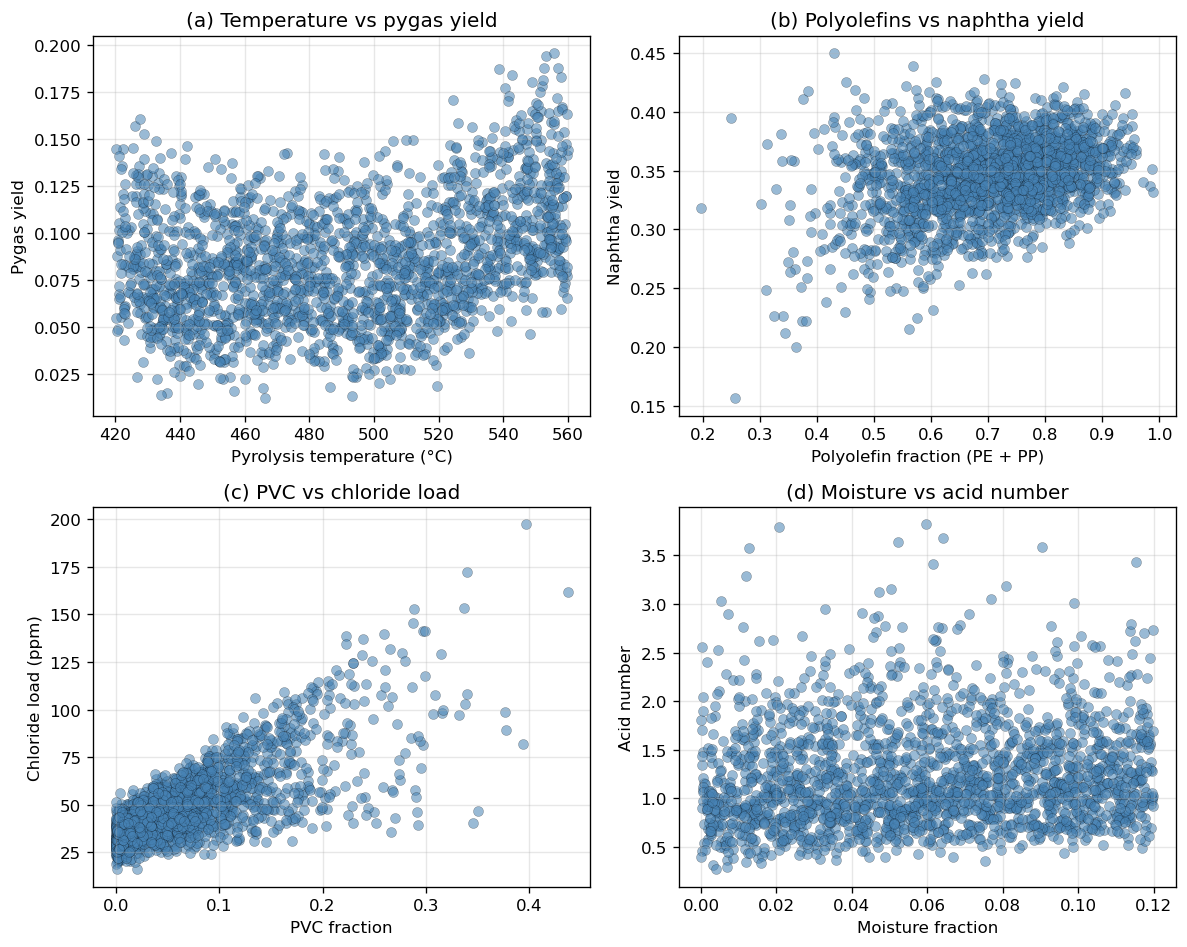

In [36]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay

yield_cols = [
    "pygas_yield",
    "naphtha_yield",
    "gas_oil_yield",
    "heavy_residue_yield"
]

print("Checking yield sum consistency")
yield_sum = df[yield_cols].sum(axis=1)

print("Min sum:", yield_sum.min())
print("Max sum:", yield_sum.max())
print("Mean sum:", yield_sum.mean())
print("\nChecking bounds")
print("Any negative yields:", (df[yield_cols] < 0).any().any())
print("Any yields > 1:", (df[yield_cols] > 1).any().any())
print("All yield sums close to 1:", np.allclose(yield_sum, 1.0, atol=1e-6))

df["polyolefin_frac"] = df["polymer_PE"] + df["polymer_PP"]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

point_color = "steelblue"

axes[0].scatter(
    df["pyrolysis_temp_C"],
    df["pygas_yield"],
    color=point_color,
    alpha=0.55,
    edgecolor="black",
    linewidth=0.2
)
axes[0].set_xlabel("Pyrolysis temperature (°C)")
axes[0].set_ylabel("Pygas yield")
axes[0].set_title("(a) Temperature vs pygas yield")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(
    df["polyolefin_frac"],
    df["naphtha_yield"],
    color=point_color,
    alpha=0.55,
    edgecolor="black",
    linewidth=0.2
)
axes[1].set_xlabel("Polyolefin fraction (PE + PP)")
axes[1].set_ylabel("Naphtha yield")
axes[1].set_title("(b) Polyolefins vs naphtha yield")
axes[1].grid(True, alpha=0.3)

axes[2].scatter(
    df["polymer_PVC"],
    df["chloride_load_ppm"],
    color=point_color,
    alpha=0.55,
    edgecolor="black",
    linewidth=0.2
)
axes[2].set_xlabel("PVC fraction")
axes[2].set_ylabel("Chloride load (ppm)")
axes[2].set_title("(c) PVC vs chloride load")
axes[2].grid(True, alpha=0.3)

axes[3].scatter(
    df["moisture_frac"],
    df["acid_number"],
    color=point_color,
    alpha=0.55,
    edgecolor="black",
    linewidth=0.2
)
axes[3].set_xlabel("Moisture fraction")
axes[3].set_ylabel("Acid number")
axes[3].set_title("(d) Moisture vs acid number")
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Data Preparation for Model

Inputs show that the model should be able to predict the outputs

80% of the data is used to train the model and 20% is used for testing in order to see if the model can predict unseen scenarios.

In [37]:
input_cols = [
    "polymer_PE","polymer_PP","polymer_PS","polymer_PET","polymer_PVC",
    "inert_contaminant_frac","moisture_frac",
    "sorting_efficiency_total","sorting_false_negative_rate","sorting_false_positive_rate",
    "PVC_capture_efficiency","metal_removal_efficiency",
    "feed_LHV","feed_Cl_ppm","feed_Ca_ppm","feed_Si_ppm",
    "feed_acid_precursor_index",
    "pyrolysis_temp_C","residence_time_s","quench_temp_F",
    "catalyst_flag","batch_vs_continuous", "feed_H_C_ratio",
    "feed_O_C_ratio", "polyolefin_frac", "oxygenated_polymer_frac",
    "halogenated_polymer_frac"
]
output_cols = [
    "pygas_yield","naphtha_yield","gas_oil_yield","heavy_residue_yield",
    "chloride_load_ppm","acid_number", "corrosion_index", "fouling_index"
]
X = df[input_cols]
y = df[output_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (1600, 27)
X_test: (400, 27)


# Surrogate Model Development

A Random Forest-based multi-output regressor is used as the baseline surrogate model.

This model is used due to a true pyrolysis system being complex. This is a baseline model to rapidly approximate the sorting to pyrolysis system. Tree models were used to their ability to capture nonlinear interactions as linear regression would likely be too simple due to the amount of DOF.


In [38]:
model = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        min_samples_leaf=2
    )
)

model.fit(X_train, y_train)
print("Model training complete.")

Model training complete.


# Model Performance 

MAE = Mean absolute error shows average prediction error
RMSE = Root mean squared error whiochc penalizes error higher than MAE
R^2 = Prediction accuracy

Parity Plots generated for Naptha since a high naptha yield means valuable product formation. Better pairty plot means the model can reproduce product yield and contaminant issues for unforseen cases


In [39]:
y_pred = model.predict(X_test)

metrics = []
for i, col in enumerate(output_cols):
    mae = mean_absolute_error(y_test.iloc[:, i], y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred[:, i]))
    r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])
    metrics.append({"target": col, "MAE": mae, "RMSE": rmse, "R2": r2})

metrics_df = pd.DataFrame(metrics)
metrics_df

,target,MAE,RMSE,R2
0,pygas_yield,0.011134,0.013746,0.813004
1,naphtha_yield,0.011419,0.014907,0.821098
2,gas_oil_yield,0.012578,0.016370,0.819008
3,heavy_residue_yield,0.013243,0.016992,0.877321
4,chloride_load_ppm,4.875454,6.109215,0.903921
5,acid_number,0.098327,0.123938,0.951701
6,corrosion_index,0.060740,0.078509,0.918754
7,fouling_index,0.006805,0.008764,0.871042


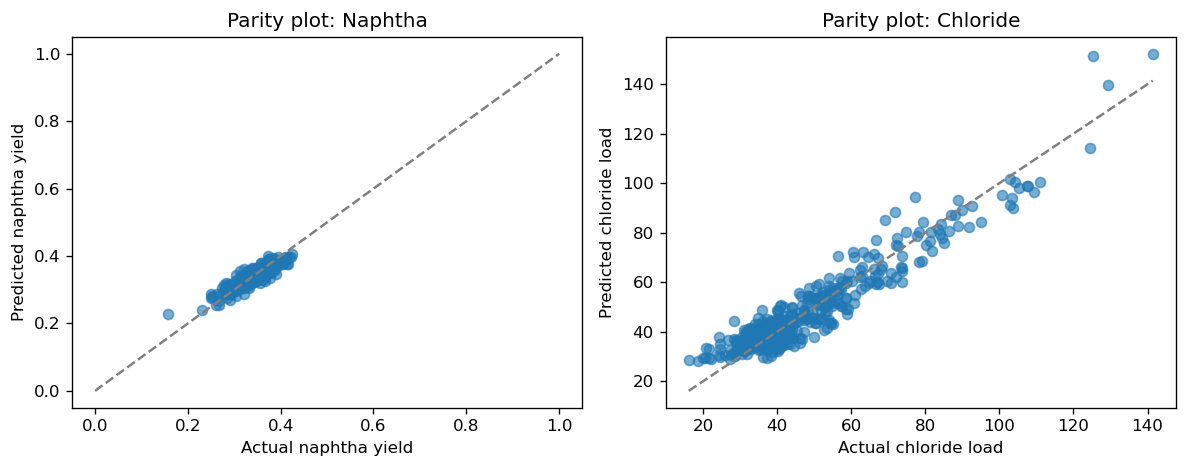

In [40]:

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(y_test["naphtha_yield"], y_pred[:, 1], alpha=0.6)
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_xlabel("Actual naphtha yield")
axes[0].set_ylabel("Predicted naphtha yield")
axes[0].set_title("Parity plot: Naphtha")

axes[1].scatter(y_test["chloride_load_ppm"], y_pred[:, 4], alpha=0.6)
axes[1].plot(
    [y_test["chloride_load_ppm"].min(), y_test["chloride_load_ppm"].max()],
    [y_test["chloride_load_ppm"].min(), y_test["chloride_load_ppm"].max()],
    "--", color="gray"
)
axes[1].set_xlabel("Actual chloride load")
axes[1].set_ylabel("Predicted chloride load")
axes[1].set_title("Parity plot: Chloride")

plt.tight_layout()
plt.show()

Feature Importance shows what the model relied on the most during its training which validates consistency

In [41]:
# not used in final report
feature_importance_table = pd.DataFrame(index=input_cols)

for idx, target_name in enumerate(output_cols):
    estimator = model.estimators_[idx]
    feature_importance_table[target_name] = estimator.feature_importances_

feature_importance_table.head()

,pygas_yield,naphtha_yield,gas_oil_yield,heavy_residue_yield,chloride_load_ppm,acid_number,corrosion_index,fouling_index
polymer_PE,0.006203,0.005520,0.004654,0.003909,0.002505,0.001593,0.002093,0.003936
polymer_PP,0.006924,0.005835,0.004850,0.003830,0.002685,0.001185,0.002186,0.003713
polymer_PS,0.021432,0.080210,0.005132,0.003813,0.003314,0.002285,0.011493,0.004013
polymer_PET,0.002881,0.029116,0.019970,0.112677,0.001036,0.366393,0.019451,0.106049
polymer_PVC,0.012059,0.007060,0.003657,0.002808,0.038218,0.003031,0.004044,0.003101


# Economic Model 

- naphtha and gas oil generate positive value,
- chloride load increases penalty,
- poor sorting efficiency increases sorting and processing burden.


In [42]:
# Prices used in our design project 
econ = {
    "price_pygas": 504.93,
    "price_naphtha": 855.11,
    "price_gas_oil": 1140.60,
    "price_residue": 347.10,

    # Assumptions
    "sorting_base_cost": 120.0,
    "sorting_efficiency_cost_coeff": 180.0,

    # limits from prompt
    "chloride_limit": 40.0,
    "acid_number_limit": 2.0,

    # Penalty coefficients
    "chloride_penalty_coeff": 75.0,
    "acid_penalty_coeff": 500.0,
    "residue_penalty_coeff": 50.0,
    "corrosion_penalty_coeff": 100.0,
    "fouling_penalty_coeff": 100.0,
}


def profit_proxy_from_prediction(pred_row, sorting_efficiency):
    
    pred = dict(zip(output_cols, pred_row))

    pygas = max(pred["pygas_yield"], 0)
    naphtha = max(pred["naphtha_yield"], 0)
    gas_oil = max(pred["gas_oil_yield"], 0)
    residue = max(pred["heavy_residue_yield"], 0)

    chloride = max(pred["chloride_load_ppm"], 0)
    acid_no = max(pred["acid_number"], 0)
    corrosion = max(pred["corrosion_index"], 0)
    fouling = max(pred["fouling_index"], 0)

    # Normalize yields 
    total_yield = pygas + naphtha + gas_oil + residue

    if total_yield > 0:
        pygas = pygas / total_yield
        naphtha = naphtha / total_yield
        gas_oil = gas_oil / total_yield
        residue = residue / total_yield

    revenue = (
        econ["price_pygas"] * pygas
        + econ["price_naphtha"] * naphtha
        + econ["price_gas_oil"] * gas_oil
        + econ["price_residue"] * residue
    )

    sorting_cost = (
        econ["sorting_base_cost"]
        + econ["sorting_efficiency_cost_coeff"] * max(sorting_efficiency - 0.70, 0) ** 2
    )

    chloride_penalty = (
        econ["chloride_penalty_coeff"]
        * max(0, chloride - econ["chloride_limit"]) ** 2
    )

    acid_penalty = (
        econ["acid_penalty_coeff"]
        * max(0, acid_no - econ["acid_number_limit"]) ** 2
    )

    residue_penalty = econ["residue_penalty_coeff"] * residue
    corrosion_penalty = econ["corrosion_penalty_coeff"] * corrosion
    fouling_penalty = econ["fouling_penalty_coeff"] * fouling

    profit_proxy = (
        revenue
        - sorting_cost
        - chloride_penalty
        - acid_penalty
        - residue_penalty
        - corrosion_penalty
        - fouling_penalty
    )

    return profit_proxy

In [43]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

feature_columns = list(X.columns)
baseline = X.median().copy()

sorting_range = np.linspace(0.70, 0.98, 30)
sorting_results = []

for eff in sorting_range:
    sample = baseline.copy()

    sample["sorting_efficiency_total"] = eff
    sample["sorting_false_negative_rate"] = max(0.02, 0.30 - 0.30 * eff)
    sample["sorting_false_positive_rate"] = max(0.005, 0.08 - 0.07 * eff)
    sample["PVC_capture_efficiency"] = min(0.99, 0.65 + 0.35 * eff)
    sample["metal_removal_efficiency"] = min(0.98, 0.60 + 0.35 * eff)

    sample_df = pd.DataFrame([sample])[feature_columns]

    pred = np.array(model.predict(sample_df)).flatten()
    pred_dict = dict(zip(output_cols, pred))

    profit_proxy = profit_proxy_from_prediction(
        pred_row=pred,
        sorting_efficiency=eff
    )

    sorting_results.append({
        "sorting_efficiency_total": eff,
        "profit_proxy": profit_proxy,
        "predicted_pygas_yield": pred_dict["pygas_yield"],
        "predicted_naphtha_yield": pred_dict["naphtha_yield"],
        "predicted_gas_oil_yield": pred_dict["gas_oil_yield"],
        "predicted_heavy_residue_yield": pred_dict["heavy_residue_yield"],
        "predicted_chloride_load_ppm": pred_dict["chloride_load_ppm"],
        "predicted_acid_number": pred_dict["acid_number"],
        "predicted_corrosion_index": pred_dict["corrosion_index"],
        "predicted_fouling_index": pred_dict["fouling_index"],
        "false_positive_rate": sample["sorting_false_positive_rate"],
        "false_negative_rate": sample["sorting_false_negative_rate"],
        "PVC_capture_efficiency": sample["PVC_capture_efficiency"],
        "metal_removal_efficiency": sample["metal_removal_efficiency"]
    })

sorting_sweep_df = pd.DataFrame(sorting_results)
display(sorting_sweep_df.head())

,sorting_efficiency_total,profit_proxy,predicted_pygas_yield,predicted_naphtha_yield,predicted_gas_oil_yield,predicted_heavy_residue_yield,predicted_chloride_load_ppm,predicted_acid_number,predicted_corrosion_index,predicted_fouling_index,false_positive_rate,false_negative_rate,PVC_capture_efficiency,metal_removal_efficiency
0,0.700000,324.552474,0.074663,0.352571,0.484487,0.087357,42.302688,1.100174,0.709505,0.054120,0.031000,0.090000,0.895000,0.845000
1,0.709655,355.623348,0.075076,0.352660,0.484393,0.087391,42.210366,1.099493,0.708917,0.054142,0.030324,0.087103,0.898379,0.848379
2,0.719310,426.949784,0.075180,0.352627,0.484409,0.087338,41.983788,1.097506,0.707859,0.054113,0.029648,0.084207,0.901759,0.851759
3,0.728966,502.798848,0.074765,0.352554,0.484693,0.087235,41.710880,1.096143,0.707932,0.053974,0.028972,0.081310,0.905138,0.855138
4,0.738621,558.000037,0.074841,0.352571,0.484928,0.086776,41.481353,1.099019,0.707447,0.053854,0.028297,0.078414,0.908517,0.858517


# Sensitivity Analysis

Sensitivity Analysis was performed to identify which upstream imporvements have the largest downstream impact which will in turn help with desicion making and economic analysis.

In [44]:

import numpy as np
import pandas as pd

feature_columns = list(X.columns)
baseline = X.mean().copy()

sorting_range = np.linspace(0.70, 0.98, 30)
sorting_results = []

for eff in sorting_range:
    sample = baseline.copy()
    sample["sorting_efficiency_total"] = eff
    sample["sorting_false_negative_rate"] = max(0.02, 0.30 - 0.30 * eff)
    sample["sorting_false_positive_rate"] = max(0.005, 0.08 - 0.07 * eff)
    sample["PVC_capture_efficiency"] = min(0.99, 0.65 + 0.35 * eff)
    sample["metal_removal_efficiency"] = min(0.98, 0.60 + 0.35 * eff)

    sample_df = pd.DataFrame([sample])[feature_columns]
    pred = np.array(model.predict(sample_df)).flatten()
    pred_dict = dict(zip(output_cols, pred))

    # economic screening score
    profit_proxy = profit_proxy_from_prediction(
        pred_row=pred,
        sorting_efficiency=eff
    )

    sorting_results.append({
        "sorting_efficiency_total": eff,
        "profit_proxy": profit_proxy,
        "predicted_pygas_yield": pred_dict["pygas_yield"],
        "predicted_naphtha_yield": pred_dict["naphtha_yield"],
        "predicted_gas_oil_yield": pred_dict["gas_oil_yield"],
        "predicted_heavy_residue_yield": pred_dict["heavy_residue_yield"],
        "predicted_chloride_load_ppm": pred_dict["chloride_load_ppm"],
        "predicted_acid_number": pred_dict["acid_number"],
        "predicted_corrosion_index": pred_dict["corrosion_index"],
        "predicted_fouling_index": pred_dict["fouling_index"],
        "false_positive_rate": sample["sorting_false_positive_rate"],
        "false_negative_rate": sample["sorting_false_negative_rate"],
        "PVC_capture_efficiency": sample["PVC_capture_efficiency"],
        "metal_removal_efficiency": sample["metal_removal_efficiency"]
    })

sorting_sweep_df["profit_proxy_relative"] = (
    sorting_sweep_df["profit_proxy"] - sorting_sweep_df["profit_proxy"].iloc[0]
)

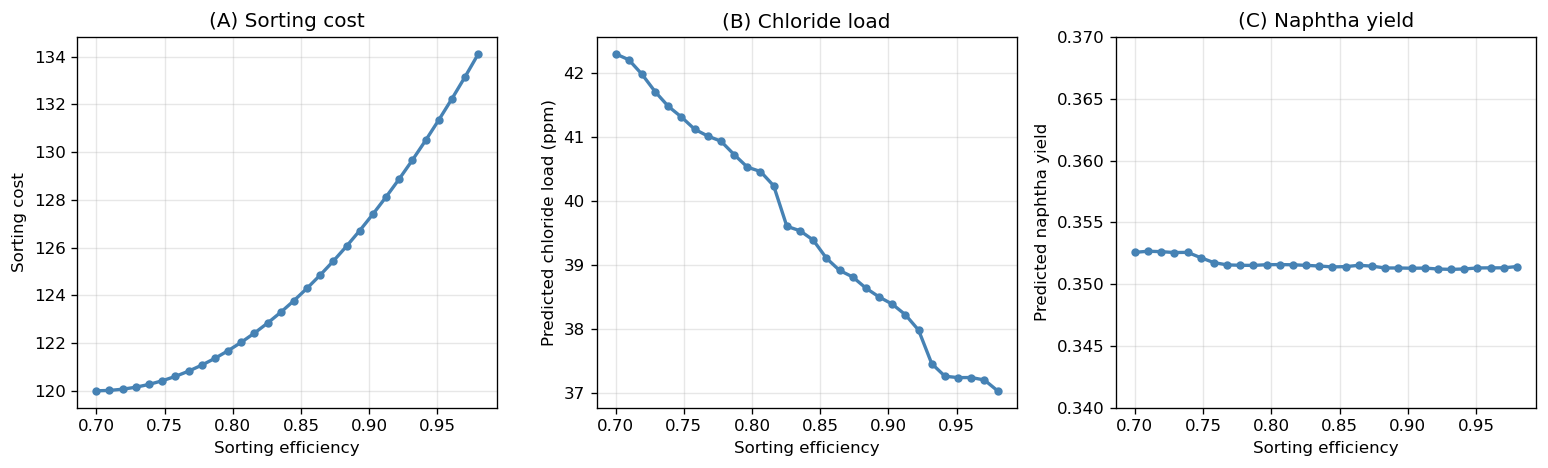

In [45]:

import matplotlib.pyplot as plt

# sorting cost calc
sorting_sweep_df["sorting_cost"] = (
    econ["sorting_base_cost"]
    + econ["sorting_efficiency_cost_coeff"]
    * (sorting_sweep_df["sorting_efficiency_total"] - 0.70).clip(lower=0) ** 2
)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

line_color = "steelblue"

axes[0].plot(
    sorting_sweep_df["sorting_efficiency_total"],
    sorting_sweep_df["sorting_cost"],
    color=line_color,
    marker="o",
    linewidth=2,
    markersize=4
)
axes[0].set_xlabel("Sorting efficiency")
axes[0].set_ylabel("Sorting cost")
axes[0].set_title("(A) Sorting cost")
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    sorting_sweep_df["sorting_efficiency_total"],
    sorting_sweep_df["predicted_chloride_load_ppm"],
    color=line_color,
    marker="o",
    linewidth=2,
    markersize=4
)
axes[1].set_xlabel("Sorting efficiency")
axes[1].set_ylabel("Predicted chloride load (ppm)")
axes[1].set_title("(B) Chloride load")
axes[1].grid(True, alpha=0.3)

axes[2].plot(
    sorting_sweep_df["sorting_efficiency_total"],
    sorting_sweep_df["predicted_naphtha_yield"],
    color=line_color,
    marker="o",
    linewidth=2,
    markersize=4
)
axes[2].set_xlabel("Sorting efficiency")
axes[2].set_ylabel("Predicted naphtha yield")
axes[2].set_title("(C) Naphtha yield")
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(0.34, 0.37)

plt.tight_layout()
plt.savefig("sorting_efficiency_sensitivity_panel_clean.png", dpi=300, bbox_inches="tight")
plt.show()

## Model Optimization

Model optimization is done to improve the surrogate model. This will not only increase predidctive accuracy, to make the project more defenisble. Bayesian optimization will be able to compare several models, tune paramters, keep consistency, predict uncertainty, and connect all decisions to economic performance. 

In [46]:

from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import KFold, cross_validate, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [47]:
from sklearn.model_selection import train_test_split

X = df[input_cols]
y = df[output_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [48]:

def evaluate_multioutput_model(model, X_test, y_test, output_cols):
    pred = model.predict(X_test)
    rows = []
    for i, target in enumerate(output_cols):
        rows.append({
            "target": target,
            "MAE": mean_absolute_error(y_test.iloc[:, i], pred[:, i]),
            "RMSE": np.sqrt(mean_squared_error(y_test.iloc[:, i], pred[:, i])),
            "R2": r2_score(y_test.iloc[:, i], pred[:, i])
        })
    return pd.DataFrame(rows), pred

def weighted_mean_r2(metrics_df):
    return metrics_df["R2"].mean()


In [49]:

candidate_models = {
    "RandomForest": MultiOutputRegressor(
        RandomForestRegressor(n_estimators=300, min_samples_leaf=2, random_state=42, n_jobs=-1)
    ),
    "ExtraTrees": MultiOutputRegressor(
        ExtraTreesRegressor(n_estimators=400, min_samples_leaf=2, random_state=42, n_jobs=-1)
    ),
    "GradientBoosting": MultiOutputRegressor(
        GradientBoostingRegressor(random_state=42)
    )
}

model_comparison = []
model_results = {}

for name, candidate in candidate_models.items():
    candidate.fit(X_train, y_train)
    mdf, pred = evaluate_multioutput_model(candidate, X_test, y_test, output_cols)
    model_results[name] = {"model": candidate, "metrics": mdf, "pred": pred}
    model_comparison.append({
        "model": name,
        "mean_R2": mdf["R2"].mean(),
        "mean_MAE": mdf["MAE"].mean(),
        "mean_RMSE": mdf["RMSE"].mean()
    })

model_comparison_df = pd.DataFrame(model_comparison).sort_values("mean_R2", ascending=False)
display(model_comparison_df)

best_model_name = model_comparison_df.iloc[0]["model"]
best_model = model_results[best_model_name]["model"]
best_metrics_df = model_results[best_model_name]["metrics"]

print(f"Best screening model: {best_model_name}")
display(best_metrics_df)


,model,mean_R2,mean_MAE,mean_RMSE
2,GradientBoosting,0.899013,0.576355,0.724749
1,ExtraTrees,0.878220,0.595917,0.737886
0,RandomForest,0.871981,0.636213,0.797805


Best screening model: GradientBoosting


,target,MAE,RMSE,R2
0,pygas_yield,0.010289,0.012652,0.841573
1,naphtha_yield,0.010216,0.013162,0.860532
2,gas_oil_yield,0.011149,0.014224,0.863346
3,heavy_residue_yield,0.011083,0.014471,0.911021
4,chloride_load_ppm,4.407064,5.539802,0.920997
5,acid_number,0.098801,0.124155,0.951531
6,corrosion_index,0.056632,0.072287,0.931122
7,fouling_index,0.005607,0.007240,0.911986


In [50]:
# paramter tuning
param_dist = {
    "estimator__n_estimators": [300, 500, 700],
    "estimator__max_depth": [None, 8, 12, 20],
    "estimator__min_samples_leaf": [1, 2, 4, 6],
    "estimator__max_features": ["sqrt", 0.6, 0.8, 1.0]
}

tuner = RandomizedSearchCV(
    estimator=MultiOutputRegressor(
        ExtraTreesRegressor(random_state=42, n_jobs=-1)
    ),
    param_distributions=param_dist,
    n_iter=20,
    scoring="r2",
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1,
    verbose=1
)

tuner.fit(X_train, y_train)

optimized_model = tuner.best_estimator_
optimized_metrics_df, optimized_pred = evaluate_multioutput_model(
    optimized_model, X_test, y_test, output_cols
)

print("Best tuned parameters:")
print(tuner.best_params_)
display(optimized_metrics_df)

# optimized model uses economic results
model = optimized_model
y_pred = optimized_pred
metrics_df = optimized_metrics_df


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best tuned parameters:
{'estimator__n_estimators': 500, 'estimator__min_samples_leaf': 2, 'estimator__max_features': 1.0, 'estimator__max_depth': 12}


,target,MAE,RMSE,R2
0,pygas_yield,0.011252,0.013708,0.814026
1,naphtha_yield,0.011578,0.015081,0.816906
2,gas_oil_yield,0.012511,0.016190,0.822970
3,heavy_residue_yield,0.012758,0.016652,0.882186
4,chloride_load_ppm,4.589224,5.688041,0.916712
5,acid_number,0.094719,0.120261,0.954524
6,corrosion_index,0.055704,0.069910,0.935578
7,fouling_index,0.006526,0.008494,0.878869


In [51]:
# Parameter tuning - faster thesis-safe version
param_dist = {
    "estimator__n_estimators": [200, 300],
    "estimator__max_depth": [8, 12, None],
    "estimator__min_samples_leaf": [2, 4],
    "estimator__max_features": ["sqrt", 0.8]
}

tuner = RandomizedSearchCV(
    estimator=MultiOutputRegressor(
        ExtraTreesRegressor(random_state=42, n_jobs=1)
    ),
    param_distributions=param_dist,
    n_iter=8,
    scoring="r2",
    cv=3,
    random_state=42,
    n_jobs=1,
    verbose=2
)

tuner.fit(X_train, y_train)

optimized_model = tuner.best_estimator_
optimized_metrics_df, optimized_pred = evaluate_multioutput_model(
    optimized_model, X_test, y_test, output_cols
)

print("Best tuned parameters:")
print(tuner.best_params_)
display(optimized_metrics_df)

model = optimized_model
y_pred_test = model.predict(X_test)
metrics_df = optimized_metrics_df

Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END estimator__max_depth=12, estimator__max_features=sqrt, estimator__min_samples_leaf=2, estimator__n_estimators=200; total time=   5.0s
[CV] END estimator__max_depth=12, estimator__max_features=sqrt, estimator__min_samples_leaf=2, estimator__n_estimators=200; total time=   5.2s
[CV] END estimator__max_depth=12, estimator__max_features=sqrt, estimator__min_samples_leaf=2, estimator__n_estimators=200; total time=   5.2s
[CV] END estimator__max_depth=None, estimator__max_features=sqrt, estimator__min_samples_leaf=2, estimator__n_estimators=200; total time=   5.8s
[CV] END estimator__max_depth=None, estimator__max_features=sqrt, estimator__min_samples_leaf=2, estimator__n_estimators=200; total time=   5.2s
[CV] END estimator__max_depth=None, estimator__max_features=sqrt, estimator__min_samples_leaf=2, estimator__n_estimators=200; total time=   5.5s
[CV] END estimator__max_depth=8, estimator__max_features=sqrt, estimator__mi

,target,MAE,RMSE,R2
0,pygas_yield,0.011163,0.013696,0.814348
1,naphtha_yield,0.011812,0.015290,0.811794
2,gas_oil_yield,0.012608,0.016366,0.819088
3,heavy_residue_yield,0.012781,0.016749,0.880808
4,chloride_load_ppm,4.547670,5.633801,0.918293
5,acid_number,0.094277,0.120044,0.954688
6,corrosion_index,0.055806,0.070112,0.935205
7,fouling_index,0.006609,0.008591,0.876086


X_test: (400, 27)
y_test: (400, 8)
y_pred: (400, 8)


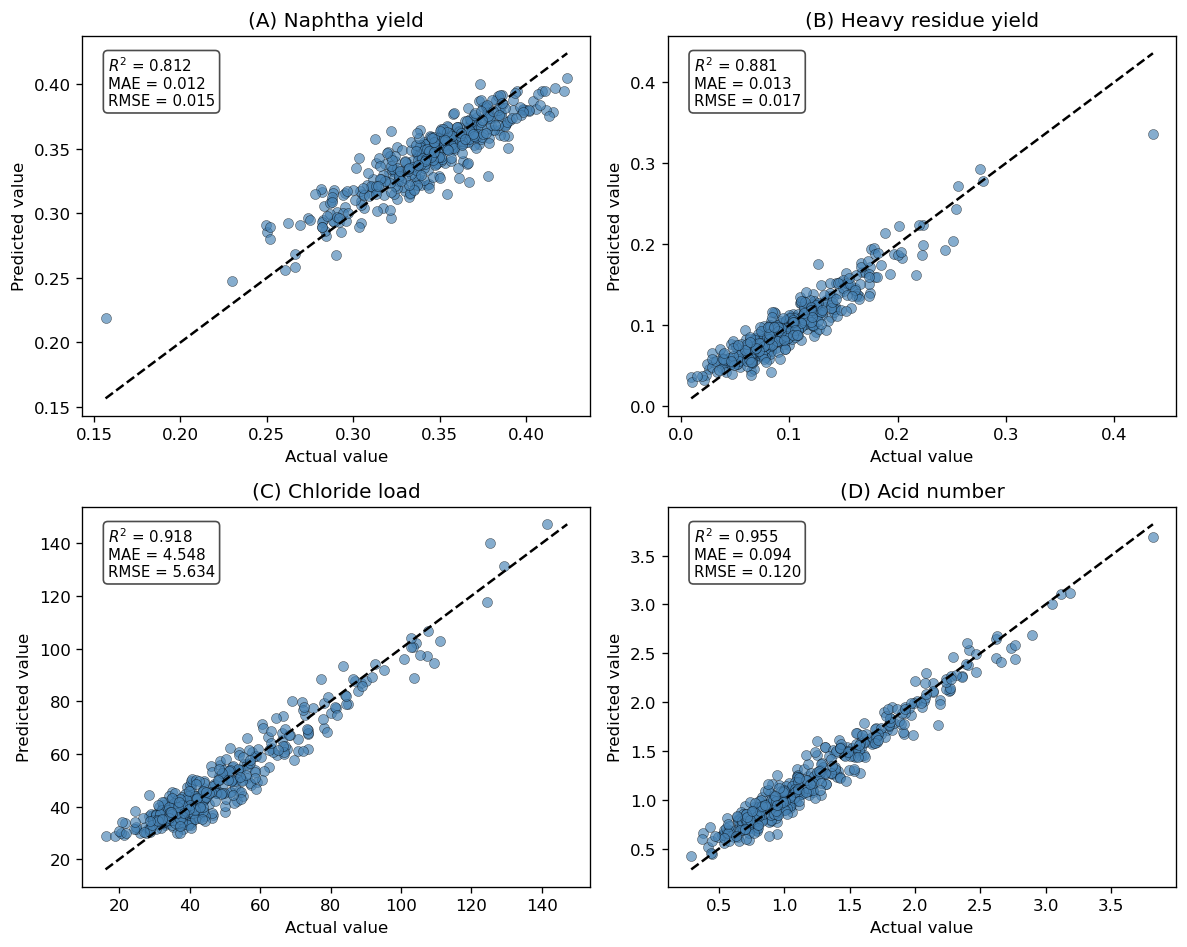

In [52]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

y_pred_test = model.predict(X_test)

parity_targets = [
    "naphtha_yield",
    "heavy_residue_yield",
    "chloride_load_ppm",
    "acid_number"
]

clean_titles = {
    "naphtha_yield": "(A) Naphtha yield",
    "heavy_residue_yield": "(B) Heavy residue yield",
    "chloride_load_ppm": "(C) Chloride load",
    "acid_number": "(D) Acid number"
}

y_test_df = pd.DataFrame(np.asarray(y_test), columns=output_cols)
y_pred_df = pd.DataFrame(np.asarray(y_pred_test), columns=output_cols)

print("X_test:", X_test.shape)
print("y_test:", y_test_df.shape)
print("y_pred:", y_pred_df.shape)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, target in zip(axes, parity_targets):
    actual = y_test_df[target].to_numpy()
    predicted = y_pred_df[target].to_numpy()

    r2 = r2_score(actual, predicted)
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))

    ax.scatter(
        actual,
        predicted,
        color="steelblue",
        alpha=0.65,
        edgecolor="black",
        linewidth=0.3
    )

    lower = min(actual.min(), predicted.min())
    upper = max(actual.max(), predicted.max())

    ax.plot(
        [lower, upper],
        [lower, upper],
        color="black",
        linestyle="--",
        linewidth=1.5
    )

    ax.set_title(clean_titles[target], fontsize=12)
    ax.set_xlabel("Actual value")
    ax.set_ylabel("Predicted value")

    ax.text(
        0.05,
        0.95,
        f"$R^2$ = {r2:.3f}\nMAE = {mae:.3f}\nRMSE = {rmse:.3f}",
        transform=ax.transAxes,
        verticalalignment="top",
        fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
    )

plt.tight_layout()
plt.show()

y_test: (400, 8)
y_pred: (400, 8)


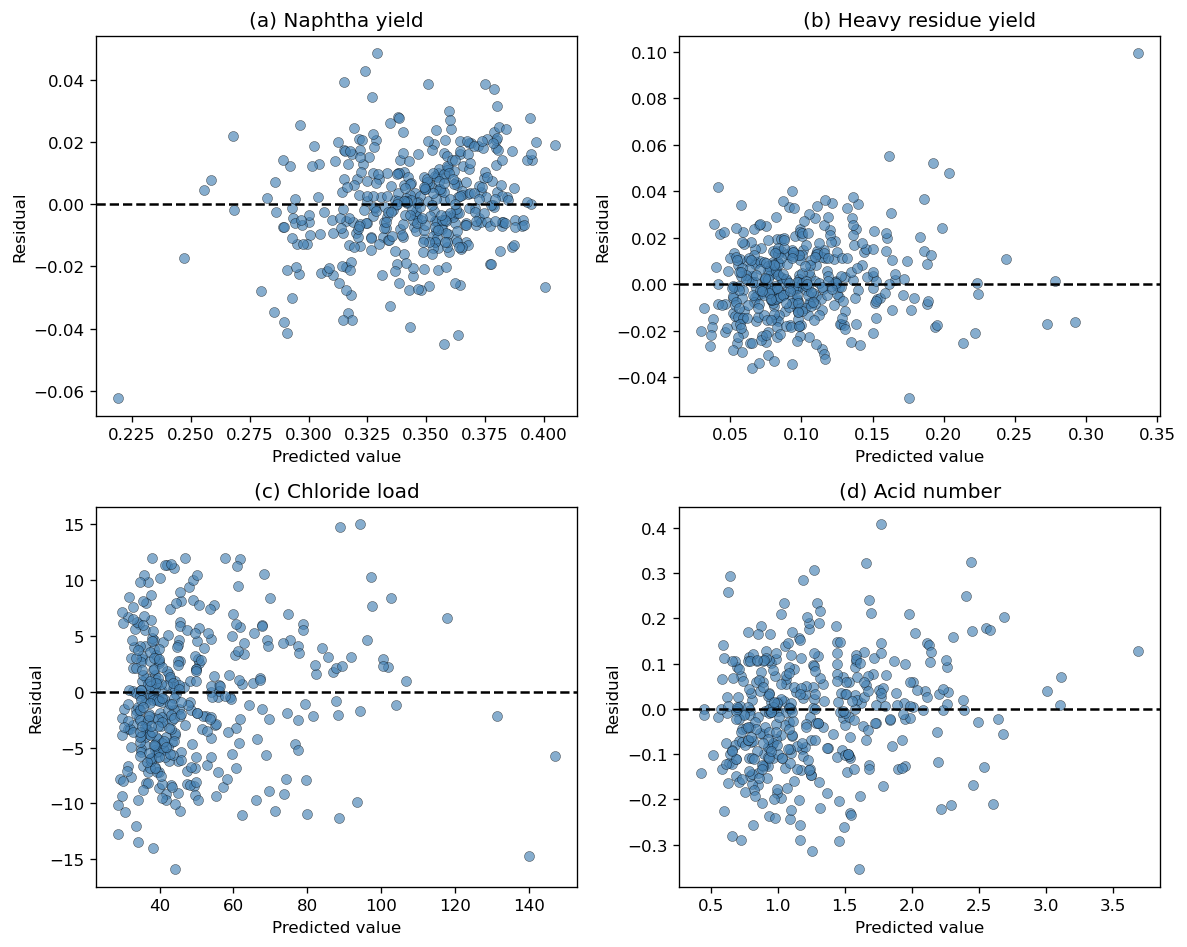

In [53]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

residual_targets = [
    "naphtha_yield",
    "heavy_residue_yield",
    "chloride_load_ppm",
    "acid_number"
]

clean_titles = {
    "naphtha_yield": "(a) Naphtha yield",
    "heavy_residue_yield": "(b) Heavy residue yield",
    "chloride_load_ppm": "(c) Chloride load",
    "acid_number": "(d) Acid number"
}

y_test_df = pd.DataFrame(np.asarray(y_test), columns=output_cols)
y_pred_df = pd.DataFrame(np.asarray(y_pred), columns=output_cols)

print("y_test:", y_test_df.shape)
print("y_pred:", y_pred_df.shape)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, target in zip(axes, residual_targets):
    actual = y_test_df[target].to_numpy()
    predicted = y_pred_df[target].to_numpy()
    residuals = actual - predicted

    ax.scatter(predicted, residuals, color="steelblue", alpha=0.65, edgecolor="black", linewidth=0.3)
    ax.axhline(0, color="black", linestyle="--", linewidth=1.5)

    ax.set_title(clean_titles[target], fontsize=12)
    ax.set_xlabel("Predicted value")
    ax.set_ylabel("Residual")

plt.tight_layout()
plt.show()

In [54]:

# sweep improvement
def predict_from_series(sample_series, trained_model=model):
    sample_df = pd.DataFrame([sample_series])[input_cols]
    return trained_model.predict(sample_df)[0]

def run_scenario(sample_series, label, trained_model=model):
    pred = predict_from_series(sample_series, trained_model)
    return {
        "scenario": label,
        "pygas_yield": pred[0],
        "naphtha_yield": pred[1],
        "gas_oil_yield": pred[2],
        "heavy_residue_yield": pred[3],
        "chloride_load_ppm": pred[4],
        "acid_number": pred[5],
        "profit_proxy": profit_proxy_from_prediction(pred, sample_series["sorting_efficiency_total"])
    }


In [55]:

baseline = X.mean().copy()

sorting_grid = np.linspace(0.70, 0.98, 8)
pvc_capture_grid = np.linspace(0.65, 0.99, 8)
temp_grid = np.linspace(420, 560, 5)

scenario_rows = []

for eff in sorting_grid:
    for pvc_cap in pvc_capture_grid:
        for temp in temp_grid:
            sample = baseline.copy()
            sample["sorting_efficiency_total"] = eff
            sample["PVC_capture_efficiency"] = pvc_cap
            sample["pyrolysis_temp_C"] = temp

            # data leakage
            sample["sorting_false_negative_rate"] = max(0.32 - 0.25 * eff, 0.02)
            sample["sorting_false_positive_rate"] = max(0.06 - 0.05 * eff, 0.001)

            label = f"eff={eff:.2f}, pvc_cap={pvc_cap:.2f}, T={temp:.0f}C"
            scenario_rows.append(run_scenario(sample, label, model))

scenario_df = pd.DataFrame(scenario_rows)
scenario_df["on_spec_chloride_50ppm"] = scenario_df["chloride_load_ppm"] <= 50
scenario_df["liquid_yield"] = scenario_df["naphtha_yield"] + scenario_df["gas_oil_yield"]

display(
    scenario_df
    .sort_values(["on_spec_chloride_50ppm", "profit_proxy"], ascending=[False, False])
    .head(15)
)


,scenario,pygas_yield,naphtha_yield,gas_oil_yield,heavy_residue_yield,chloride_load_ppm,acid_number,profit_proxy,on_spec_chloride_50ppm,liquid_yield
276,"eff=0.94, pvc_cap=0.99, T=455C",0.074715,0.354915,0.481725,0.088874,40.232035,1.251836,701.250803,True,0.836640
277,"eff=0.94, pvc_cap=0.99, T=490C",0.074003,0.355080,0.482312,0.088023,40.303355,1.252443,699.253314,True,0.837392
316,"eff=0.98, pvc_cap=0.99, T=455C",0.074715,0.355138,0.481655,0.088880,40.193169,1.252338,698.665825,True,0.836793
275,"eff=0.94, pvc_cap=0.99, T=420C",0.078508,0.353446,0.478061,0.092459,40.173667,1.251710,698.529013,True,0.831507
317,"eff=0.98, pvc_cap=0.99, T=490C",0.074003,0.355303,0.482242,0.088004,40.264488,1.252945,697.099374,True,0.837545
315,"eff=0.98, pvc_cap=0.99, T=420C",0.078508,0.353669,0.477991,0.092464,40.134801,1.252212,695.608493,True,0.831660
278,"eff=0.94, pvc_cap=0.99, T=525C",0.083465,0.351935,0.477480,0.089341,40.312011,1.250820,693.105029,True,0.829415
318,"eff=0.98, pvc_cap=0.99, T=525C",0.083481,0.352246,0.477480,0.089322,40.273145,1.251321,691.006661,True,0.829727
115,"eff=0.78, pvc_cap=0.99, T=420C",0.078576,0.353097,0.478219,0.092903,40.516228,1.242345,690.221676,True,0.831316
117,"eff=0.78, pvc_cap=0.99, T=490C",0.074701,0.354672,0.482609,0.088663,40.586347,1.243236,689.376397,True,0.837281


In [56]:

# uncertainty 
seed_models = []
for seed in range(10):
    seed_model = MultiOutputRegressor(
        ExtraTreesRegressor(
            n_estimators=300,
            min_samples_leaf=2,
            random_state=seed,
            n_jobs=-1
        )
    )
    seed_model.fit(X_train, y_train)
    seed_models.append(seed_model)

decision_cases = []

for case_name, modifier in {
    "baseline": lambda s: s,
    "improved_sorting": lambda s: s.assign(
        sorting_efficiency_total=0.95,
        sorting_false_negative_rate=0.08,
        sorting_false_positive_rate=0.01,
        PVC_capture_efficiency=0.95,
        metal_removal_efficiency=0.93
    ) if isinstance(s, pd.DataFrame) else s,
}.items():
    sample = baseline.copy()
    if case_name == "improved_sorting":
        sample["sorting_efficiency_total"] = 0.95
        sample["sorting_false_negative_rate"] = 0.08
        sample["sorting_false_positive_rate"] = 0.01
        sample["PVC_capture_efficiency"] = 0.95
        sample["metal_removal_efficiency"] = 0.93

    preds = np.array([predict_from_series(sample, m) for m in seed_models])
    for i, target in enumerate(output_cols):
        decision_cases.append({
            "case": case_name,
            "target": target,
            "mean": preds[:, i].mean(),
            "std": preds[:, i].std(),
            "p05": np.percentile(preds[:, i], 5),
            "p95": np.percentile(preds[:, i], 95)
        })

uncertainty_df = pd.DataFrame(decision_cases)
display(uncertainty_df)


,case,target,mean,std,p05,p95
0,baseline,pygas_yield,0.074423,0.000400,0.073972,0.075078
1,baseline,naphtha_yield,0.354258,0.001137,0.352293,0.355697
2,baseline,gas_oil_yield,0.482803,0.000976,0.481338,0.484146
3,baseline,heavy_residue_yield,0.087234,0.000902,0.086224,0.088667
4,baseline,chloride_load_ppm,47.899325,0.210997,47.597780,48.236946
5,baseline,acid_number,1.247941,0.006219,1.242097,1.258612
6,baseline,corrosion_index,0.787977,0.003109,0.782270,0.791058
7,baseline,fouling_index,0.053585,0.000456,0.052943,0.054219
8,improved_sorting,pygas_yield,0.074483,0.000598,0.073504,0.075273
9,improved_sorting,naphtha_yield,0.353952,0.001316,0.351704,0.355537


Bayesian Optimization

In [57]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skopt import gp_minimize
from skopt.space import Real
from skopt.plots import plot_convergence

try:
    surrogate_model = optimized_model
except NameError:
    surrogate_model = model

feature_columns = list(X.columns)
baseline = X.median().copy()

search_space = [
    Real(0.70, 0.98, name="sorting_efficiency_total"),
    Real(0.70, 0.99, name="PVC_capture_efficiency"),
    Real(0.70, 0.99, name="metal_removal_efficiency"),
    Real(0.02, 0.15, name="sorting_false_positive_rate"),
    Real(0.02, 0.20, name="sorting_false_negative_rate"),
    Real(430, 560, name="pyrolysis_temp_C"),
    Real(5, 60, name="residence_time_s"),
]

opt_var_names = [dim.name for dim in search_space]

feed_flow_lb_hr = 52432
operating_hours_yr = 8000
lb_per_metric_ton = 2204.62

feed_MT_yr = feed_flow_lb_hr * operating_hours_yr / lb_per_metric_ton

price_pygas = 504.93       # $/MT
price_naphtha = 855.11     # $/MT
price_gas_oil = 1140.60    # $/MT
price_residue = 347.10     # $/MT
chloride_limit = 40.0
acid_number_limit = 2.0
chloride_penalty = 75.0
acid_penalty = 500.0
residue_penalty = 50.0
corrosion_penalty = 100.0
fouling_penalty = 100.0
sorting_cost_factor = 1500.0
aspen_pygas = 188.57 / feed_flow_lb_hr
aspen_naphtha = 10939.5 / feed_flow_lb_hr
aspen_gas_oil = 9999.96 / feed_flow_lb_hr
aspen_residue = 31303.5 / feed_flow_lb_hr
aspen_feasibility_penalty_coeff = 5e7

def objective(params):
    candidate = baseline.copy()

    for name, value in zip(opt_var_names, params):
        candidate[name] = value

    candidate_df = pd.DataFrame([candidate])[feature_columns]
    prediction = np.array(surrogate_model.predict(candidate_df)).flatten()
    pred_dict = dict(zip(output_cols, prediction))

    pygas = max(pred_dict.get("pygas_yield", 0), 0)
    naphtha = max(pred_dict.get("naphtha_yield", 0), 0)
    gas_oil = max(pred_dict.get("gas_oil_yield", 0), 0)
    residue = max(pred_dict.get("heavy_residue_yield", 0), 0)

    chloride = max(pred_dict.get("chloride_load_ppm", 0), 0)
    acid_number = max(pred_dict.get("acid_number", 0), 0)
    corrosion = max(pred_dict.get("corrosion_index", 0), 0)
    fouling = max(pred_dict.get("fouling_index", 0), 0)

    total_yield = pygas + naphtha + gas_oil + residue

    if total_yield > 0:
        pygas = pygas / total_yield
        naphtha = naphtha / total_yield
        gas_oil = gas_oil / total_yield
        residue = residue / total_yield

    annual_revenue = feed_MT_yr * (
        price_pygas * pygas
        + price_naphtha * naphtha
        + price_gas_oil * gas_oil
        + price_residue * residue
    )

    chloride_cost = chloride_penalty * max(0, chloride - chloride_limit) ** 2 * feed_MT_yr
    acid_cost = acid_penalty * max(0, acid_number - acid_number_limit) ** 2 * feed_MT_yr

    residue_cost = residue_penalty * residue * feed_MT_yr
    corrosion_cost = corrosion_penalty * corrosion * feed_MT_yr
    fouling_cost = fouling_penalty * fouling * feed_MT_yr

    hard_chloride_penalty = 0
    if chloride > chloride_limit:
        hard_chloride_penalty = 1e7 * (chloride - chloride_limit)

    energy_penalty = (
        0.5 * candidate["pyrolysis_temp_C"]
        + 2.0 * candidate["residence_time_s"]
    ) * feed_MT_yr

    sorting_efficiency = candidate["sorting_efficiency_total"]
    pvc_capture = candidate["PVC_capture_efficiency"]
    metal_removal = candidate["metal_removal_efficiency"]

    sorting_cost = sorting_cost_factor * (
        (sorting_efficiency - 0.70) ** 2
        + (pvc_capture - 0.70) ** 2
        + (metal_removal - 0.70) ** 2
    ) * feed_MT_yr

    feasibility_penalty = aspen_feasibility_penalty_coeff * (
        (pygas - aspen_pygas) ** 2
        + (naphtha - aspen_naphtha) ** 2
        + (gas_oil - aspen_gas_oil) ** 2
        + (residue - aspen_residue) ** 2
    )

    objective_score = (
        annual_revenue
        - chloride_cost
        - acid_cost
        - residue_cost
        - corrosion_cost
        - fouling_cost
        - hard_chloride_penalty
        - energy_penalty
        - sorting_cost
        - feasibility_penalty
    )

    return -objective_score

result = gp_minimize(
    func=objective,
    dimensions=search_space,
    n_calls=60,
    n_initial_points=12,
    acq_func="EI",
    random_state=42
)

best_params = dict(zip(opt_var_names, result.x))
best_score = -result.fun

print("Best Bayesian Optimization Screening-Level Annual Net-Value Proxy:")
print(f"${best_score:,.2f} per year")

print("\nOptimal Conditions:")
for key, value in best_params.items():
    print(f"{key}: {value:.4f}")

optimal_case = baseline.copy()

for name, value in best_params.items():
    optimal_case[name] = value

optimal_df = pd.DataFrame([optimal_case])[feature_columns]
optimal_prediction = np.array(surrogate_model.predict(optimal_df)).flatten()
optimal_pred_dict = dict(zip(output_cols, optimal_prediction))

# Raw predicted yields
raw_pygas = max(optimal_pred_dict.get("pygas_yield", 0), 0)
raw_naphtha = max(optimal_pred_dict.get("naphtha_yield", 0), 0)
raw_gas_oil = max(optimal_pred_dict.get("gas_oil_yield", 0), 0)
raw_residue = max(optimal_pred_dict.get("heavy_residue_yield", 0), 0)

raw_total_yield = raw_pygas + raw_naphtha + raw_gas_oil + raw_residue

# Normalized yields
if raw_total_yield > 0:
    norm_pygas = raw_pygas / raw_total_yield
    norm_naphtha = raw_naphtha / raw_total_yield
    norm_gas_oil = raw_gas_oil / raw_total_yield
    norm_residue = raw_residue / raw_total_yield
else:
    norm_pygas = norm_naphtha = norm_gas_oil = norm_residue = 0

# Output table
optimal_outputs = pd.DataFrame({
    "Output": output_cols,
    "Raw Predicted Value": optimal_prediction
})

print("\nPredicted Outputs at Optimal Conditions:")
display(optimal_outputs)

economic_summary = pd.DataFrame({
    "Product": ["PyGas", "Naphtha", "Gas Oil", "Heavy Residue"],
    "Aspen Yield Fraction": [
        aspen_pygas,
        aspen_naphtha,
        aspen_gas_oil,
        aspen_residue
    ],
    "Optimized Yield Fraction": [
        norm_pygas,
        norm_naphtha,
        norm_gas_oil,
        norm_residue
    ],
    "Price ($/MT)": [
        price_pygas,
        price_naphtha,
        price_gas_oil,
        price_residue
    ]
})

economic_summary["Production (MT/yr)"] = (
    economic_summary["Optimized Yield Fraction"] * feed_MT_yr
)

economic_summary["Annual Revenue ($/yr)"] = (
    economic_summary["Production (MT/yr)"] * economic_summary["Price ($/MT)"]
)

print("\nEconomic Summary at Optimal Conditions:")
display(economic_summary)
print("\nYield Sum Check:")
print(f"Raw yield sum: {raw_total_yield:.4f}")
print(f"Normalized yield sum: {norm_pygas + norm_naphtha + norm_gas_oil + norm_residue:.4f}")


Best Bayesian Optimization Screening-Level Annual Net-Value Proxy:
$85,577,759.61 per year

Optimal Conditions:
sorting_efficiency_total: 0.7000
PVC_capture_efficiency: 0.9353
metal_removal_efficiency: 0.7000
sorting_false_positive_rate: 0.0200
sorting_false_negative_rate: 0.0200
pyrolysis_temp_C: 430.0000
residence_time_s: 5.0000

Predicted Outputs at Optimal Conditions:


,Output,Raw Predicted Value
0,pygas_yield,0.052786
1,naphtha_yield,0.368207
2,gas_oil_yield,0.503111
3,heavy_residue_yield,0.080606
4,chloride_load_ppm,40.002457
5,acid_number,1.076507
6,corrosion_index,0.692061
7,fouling_index,0.050865



Economic Summary at Optimal Conditions:


,Product,Aspen Yield Fraction,Optimized Yield Fraction,Price ($/MT),Production (MT/yr),Annual Revenue ($/yr)
0,PyGas,0.003596,0.052538,504.93,9996.079566,5.047320e+06
1,Naphtha,0.208642,0.366481,855.11,69727.420227,5.962461e+07
2,Gas Oil,0.190722,0.500753,1140.60,95274.402274,1.086700e+08
3,Heavy Residue,0.597030,0.080228,347.10,15264.365353,5.298261e+06



Yield Sum Check:
Raw yield sum: 1.0047
Normalized yield sum: 1.0000


## SHAP

SHAP is used to answer what input variables pushed a prediction higher or lower and to what magnitude. What are the top drivers?

SHAP sample shape: (300, 27)


 99%|===================| 297/300 [00:13<00:00]        

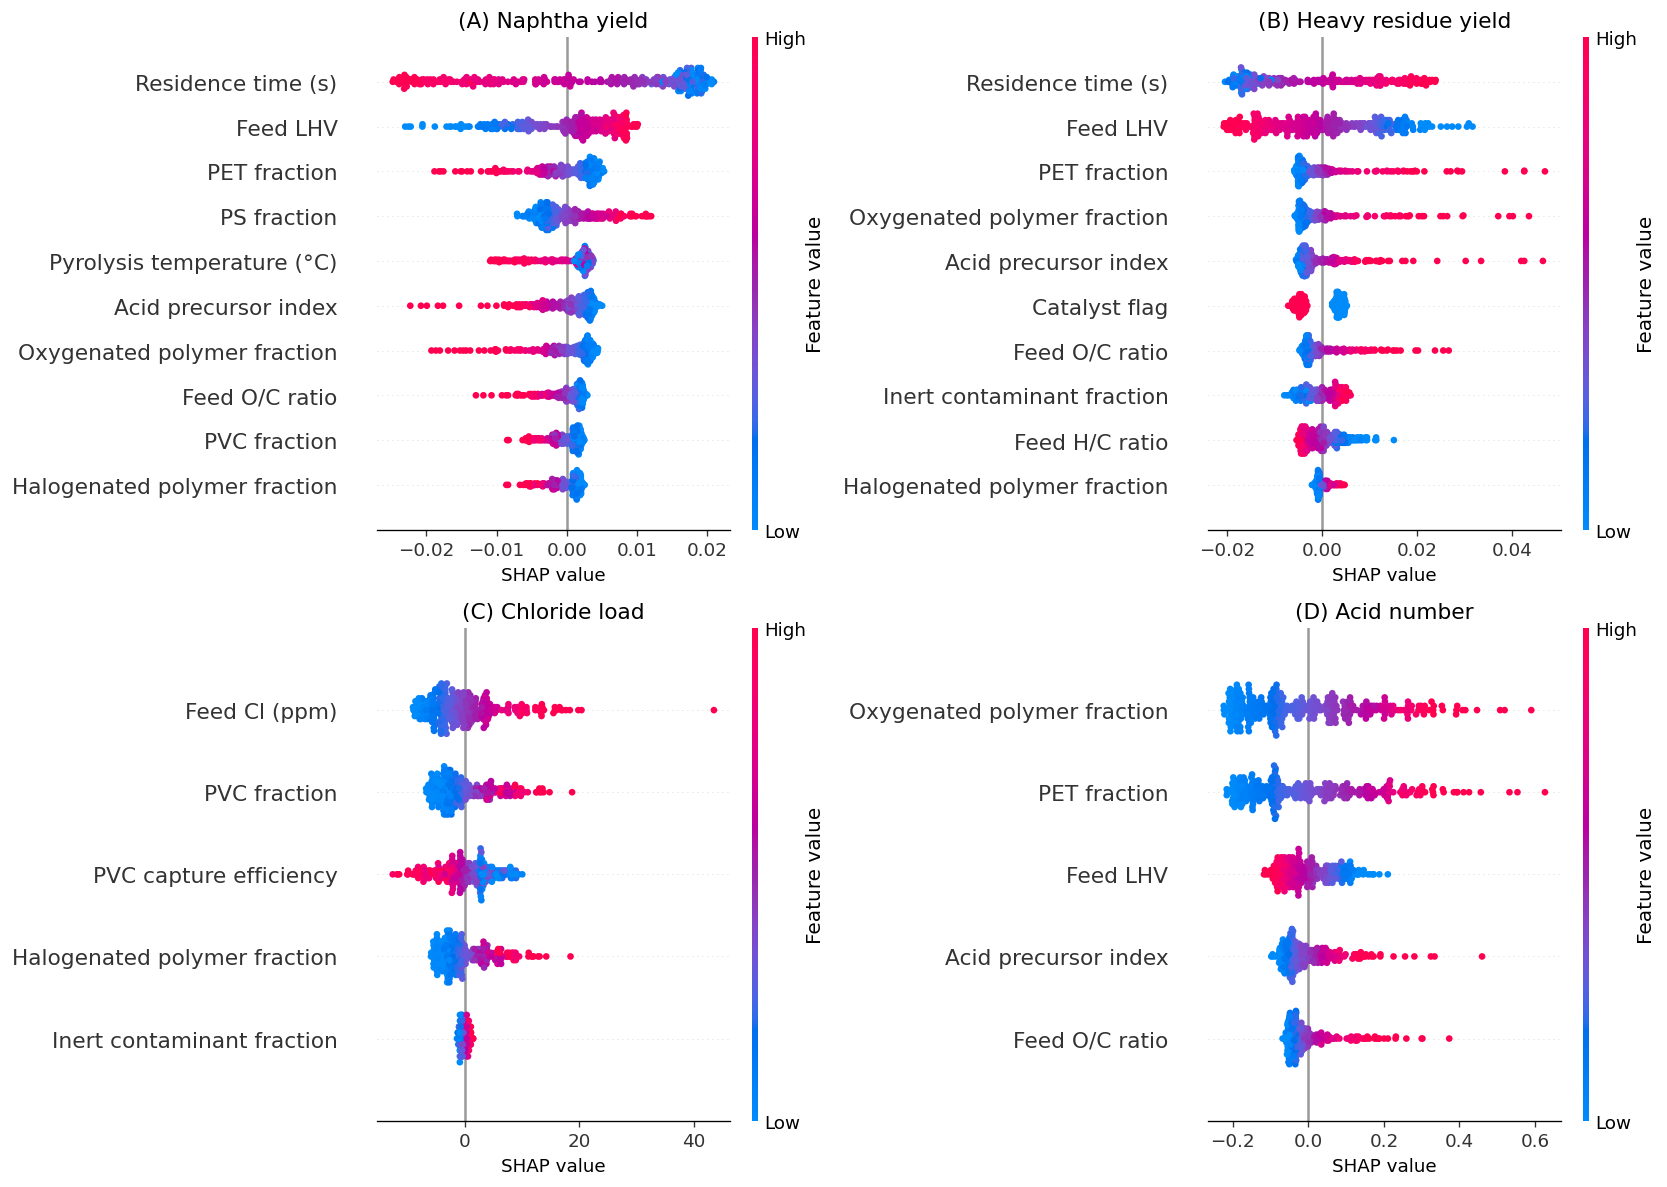

In [58]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

X_shap = X_test.copy()

if len(X_shap) > 300:
    X_shap = X_shap.sample(n=300, random_state=42)
 
print("SHAP sample shape:", X_shap.shape)

important_targets = [
    "naphtha_yield",
    "heavy_residue_yield",
    "chloride_load_ppm",
    "acid_number"
]

clean_names = {
    "residence_time_s": "Residence time (s)",
    "feed_LHV": "Feed LHV",
    "polymer_PS": "PS fraction",
    "pyrolysis_temp_C": "Pyrolysis temperature (°C)",
    "feed_acid_precursor_index": "Acid precursor index",
    "polymer_PET": "PET fraction",
    "oxygenated_polymer_frac": "Oxygenated polymer fraction",
    "feed_O_C_ratio": "Feed O/C ratio",
    "halogenated_polymer_frac": "Halogenated polymer fraction",
    "polymer_PVC": "PVC fraction",
    "inert_contaminant_frac": "Inert contaminant fraction",
    "catalyst_flag": "Catalyst flag",
    "polyolefin_frac": "Polyolefin fraction",
    "feed_H_C_ratio": "Feed H/C ratio",
    "moisture_frac": "Moisture fraction",
    "feed_Cl_ppm": "Feed Cl (ppm)",
    "PVC_capture_efficiency": "PVC capture efficiency",
    "sorting_false_positive_rate": "False positive rate",
    "sorting_false_negative_rate": "False negative rate",
    "batch_vs_continuous": "Batch vs continuous",
    "feed_Ca_ppm": "Feed Ca (ppm)",
    "feed_Si_ppm": "Feed Si (ppm)",
    "polymer_PP": "PP fraction",
}

X_shap = X_shap.rename(columns=clean_names)
max_display_map = {
    "naphtha_yield": 10,
    "heavy_residue_yield": 10,
    "chloride_load_ppm": 5,
    "acid_number": 5
}

panel_titles = {
    "naphtha_yield": "(A) Naphtha yield",
    "heavy_residue_yield": "(B) Heavy residue yield",
    "chloride_load_ppm": "(C) Chloride load",
    "acid_number": "(D) Acid number"
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, target_name in enumerate(important_targets):
    target_idx = output_cols.index(target_name)
    target_model = model.estimators_[target_idx]

    explainer = shap.Explainer(target_model, X_shap)
    shap_values = explainer(X_shap)

    plt.sca(axes[i])

    shap.summary_plot(
        shap_values,
        X_shap ,
        max_display=max_display_map[target_name],
        show=False,
        plot_size=None
    )

    axes[i].set_title(panel_titles[target_name], fontsize=13)
    axes[i].set_xlabel("SHAP value", fontsize=11)

plt.tight_layout()
plt.show()